In [14]:
import autograd.numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import matplotlib.pyplot as plt




datapath = './mlrefined_datasets/nonlinear_superlearn_datasets/'

In [7]:
csvname = datapath + 'new_circle_data.csv'

data = np.loadtxt(csvname, delimiter = ',')
x = data[:-1,:]
y = data[-1:,:] 

print(np.shape(x))
print(np.shape(y))

(2, 99)
(1, 99)


[Model 1] best degree = 1, miscls(full) = 23
[Model 2] best degree = 2, miscls(full) = 9
[Model 3] best degree = 2, miscls(full) = 12
[Model 4] best degree = 5, miscls(full) = 4
[Model 5] best degree = 2, miscls(full) = 11

Bagged model misclassifications = 7


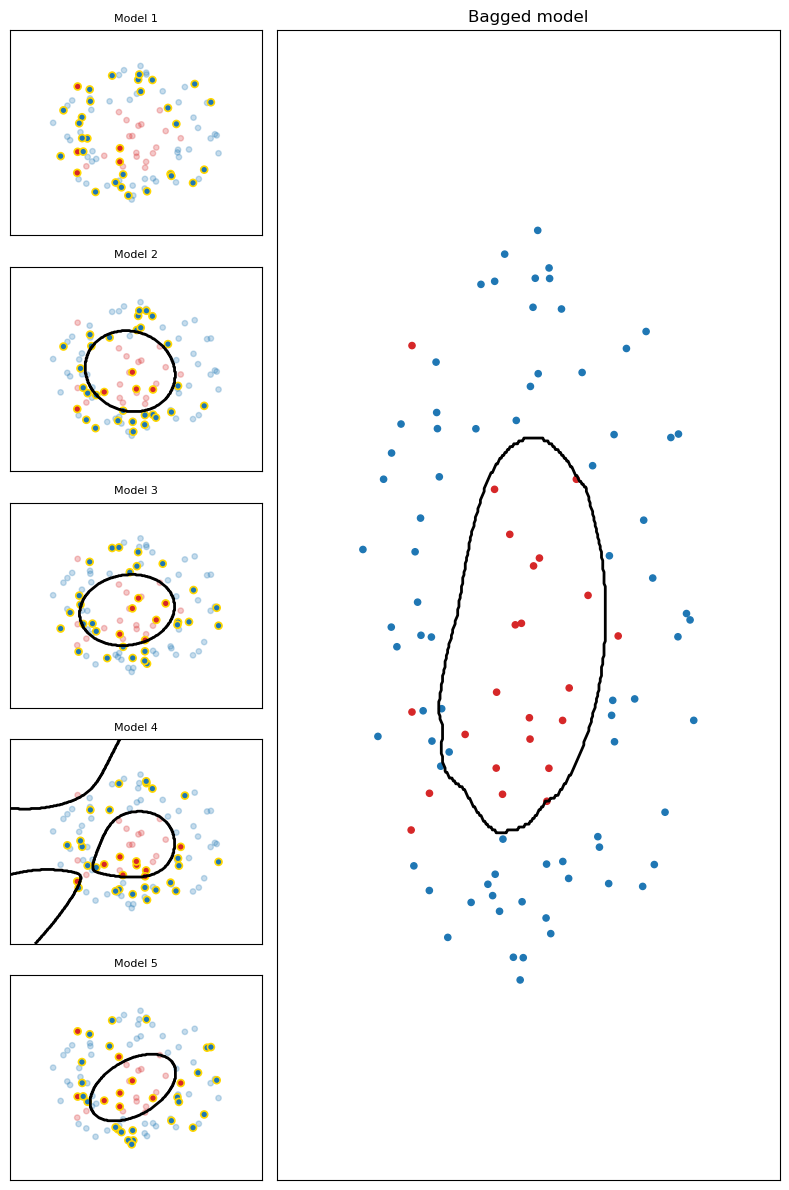

In [13]:
X = data[:-1, :].T                  
y = data[-1, :].astype(int)         
N = X.shape[0]

num_models = 5
degrees = range(1, 9)

models = []          
predictions = []     
miscls_each = []    
splits = []          

rng = np.random.RandomState(1)

for m in range(num_models):
    idx = rng.permutation(N)
    train_idx = idx[:int(2*N/3)]
    val_idx   = idx[int(2*N/3):]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val,   y_val   = X[val_idx],   y[val_idx]

    best_deg, best_acc, best_model = None, -1, None

    for d in degrees:
        poly = PolynomialFeatures(d)
        Xtr = poly.fit_transform(X_train)
        Xv  = poly.transform(X_val)

        clf = LogisticRegression(max_iter=5000, C=1e3)
        clf.fit(Xtr, y_train)
        acc = accuracy_score(y_val, clf.predict(Xv))

        if acc > best_acc:
            best_acc  = acc
            best_deg  = d
            best_model = (poly, clf)

    poly, clf = best_model
    models.append(best_model)
    splits.append((train_idx, val_idx))

    y_pred_full = clf.predict(poly.transform(X))
    predictions.append(y_pred_full)
    miscls_each.append(np.sum(y_pred_full != y))

    print(f"[Model {m+1}] best degree = {best_deg}, "
          f"miscls(full) = {miscls_each[-1]}")

preds = np.array(predictions)                 
bag_pred, _ = mode(preds, axis=0, keepdims=False)
bag_miscls = np.sum(bag_pred != y)
print("\nBagged model misclassifications =", bag_miscls)

# ========== 4. 画决策边界（模仿 Figure 11.46） ==========

def plot_one_model(ax, poly, clf, train_idx, val_idx, title=""):
    # 网格范围稍微大一点
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(poly.transform(grid)).reshape(xx.shape)

    # 决策边界
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

    # 所有点先画得比较淡
    ax.scatter(X[:, 0], X[:, 1],
               c=['tab:red' if yi == 1 else 'tab:blue' for yi in y],
               s=15, alpha=0.25)

    # validation set 高亮（模仿书里黄色框/突出验证集的感觉）
    ax.scatter(X[val_idx, 0], X[val_idx, 1],
               c=['tab:red' if yi == 1 else 'tab:blue' for yi in y[val_idx]],
               s=25, edgecolors='gold', linewidths=1.2)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=8)

# 布局：左边 5 行 1 列小图，右边 1 个大图
fig = plt.figure(figsize=(8, 12))
gs = fig.add_gridspec(5, 2, width_ratios=[1, 2])

# --- 左边 5 个单模型 ---
for i in range(5):
    ax = fig.add_subplot(gs[i, 0])
    poly, clf = models[i]
    train_idx, val_idx = splits[i]
    plot_one_model(ax, poly, clf, train_idx, val_idx, title=f"Model {i+1}")

# --- 右边：bagged 模型的大图 ---
ax_big = fig.add_subplot(gs[:, 1])

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# 对网格点做 5 个模型的预测，然后取 mode 得到 bagged 决策边界
grid_preds = []
for (poly, clf) in models:
    grid_preds.append(clf.predict(poly.transform(grid)))
grid_preds = np.array(grid_preds)
bag_grid_pred, _ = mode(grid_preds, axis=0, keepdims=False)
Z = bag_grid_pred.reshape(xx.shape)

# bagged 边界
ax_big.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

# 全数据点
ax_big.scatter(X[:, 0], X[:, 1],
               c=['tab:red' if yi == 1 else 'tab:blue' for yi in y],
               s=20)

ax_big.set_xticks([])
ax_big.set_yticks([])
ax_big.set_title("Bagged model", fontsize=12)

plt.tight_layout()
plt.show()


In [16]:
# import data
csvname = datapath + '2eggs_multiclass.csv'
data = np.loadtxt(csvname, delimiter = ',')
x = data[:-1,:]
y = data[-1:,:]

print(np.shape(x))
print(np.shape(y))

(2, 89)
(1, 89)


Input shape: (2, 89)
Output shape: (1, 89)

Training with β = 0.01
Iteration 0: Cost = 1.1014, Misclass = 69, LR = 0.5000
Iteration 1000: Cost = 0.9425, Misclass = 35, LR = 0.0624
Converged at iteration 1002

>>> Final Results:
    Accuracy: 60.67%
    Misclassification: 35/89
    Training iterations: 1003

Training with β = 0.1
Iteration 0: Cost = 1.1264, Misclass = 69, LR = 0.3000
Iteration 1000: Cost = 0.8859, Misclass = 35, LR = 0.0651
Converged at iteration 1002

>>> Final Results:
    Accuracy: 60.67%
    Misclassification: 35/89
    Training iterations: 1003

Training with β = 100
Iteration 0: Cost = 1.1000, Misclass = 67, LR = 0.1000
Iteration 1000: Cost = 0.1887, Misclass = 1, LR = 0.1000
Converged at iteration 1175

>>> Final Results:
    Accuracy: 98.88%
    Misclassification: 1/89
    Training iterations: 1176

Improved misclassification history plots saved!
Improved decision boundary plots saved!


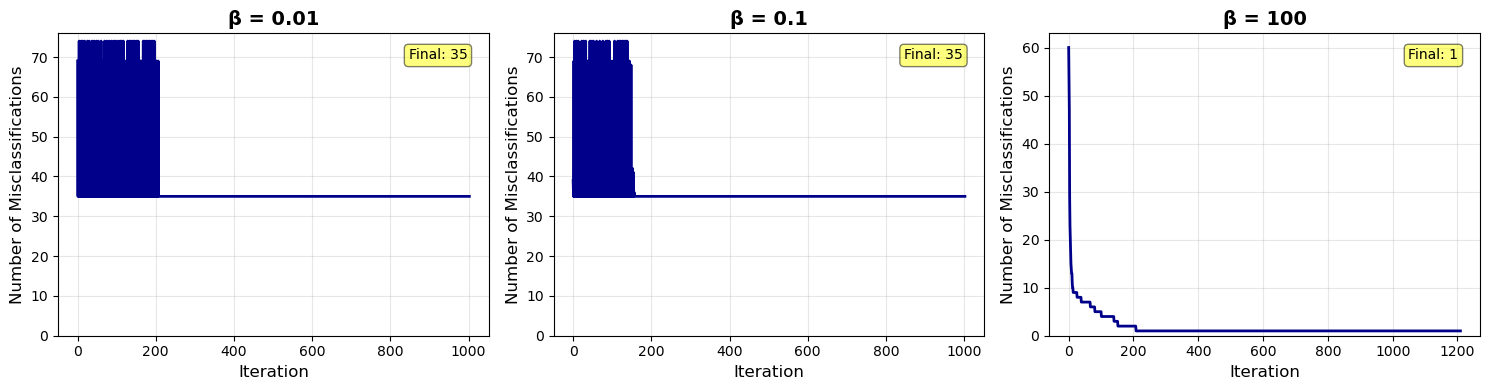

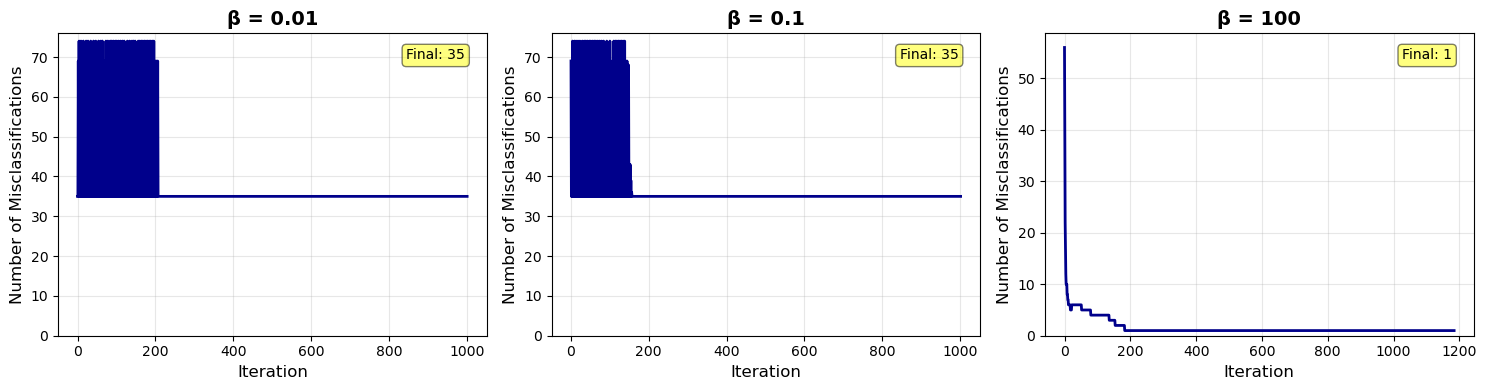

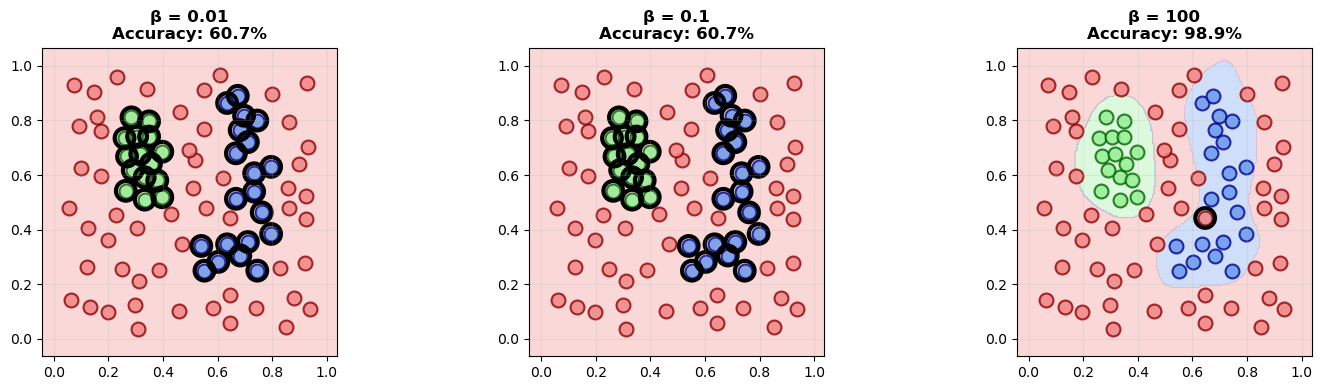

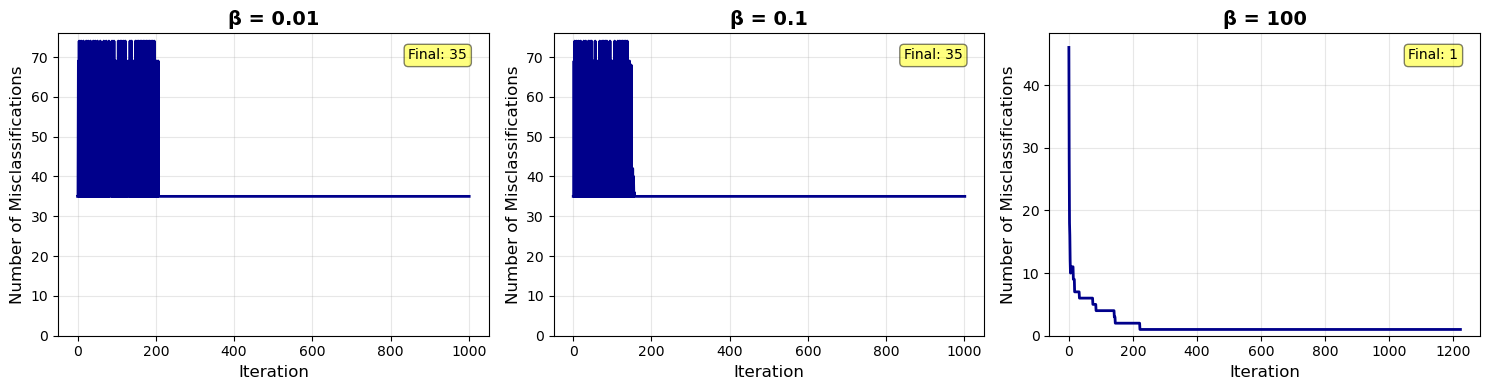

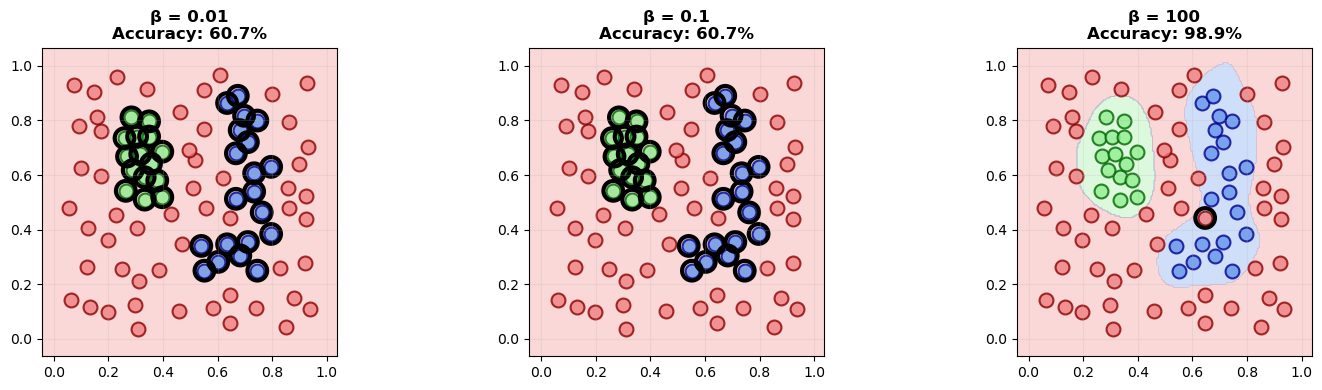

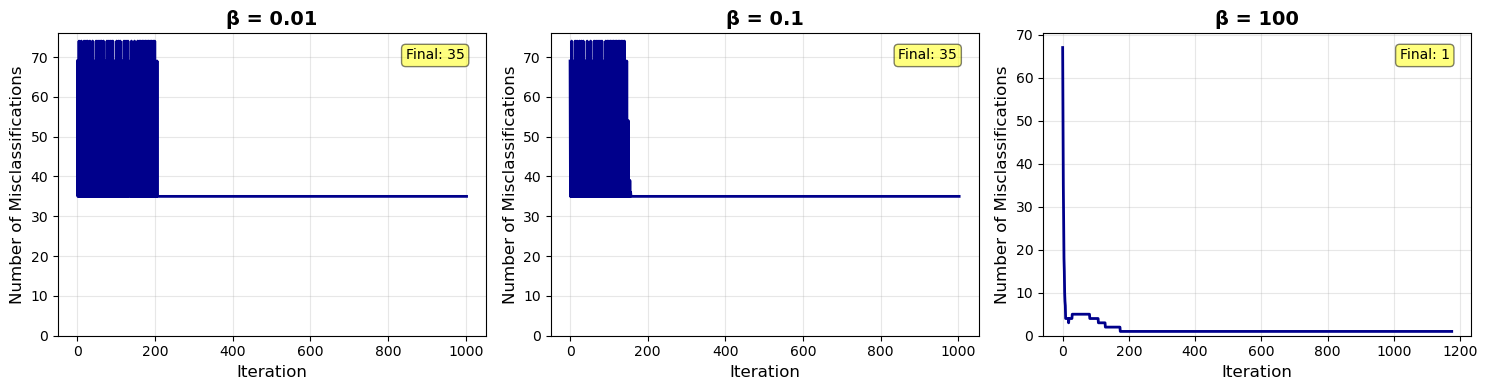

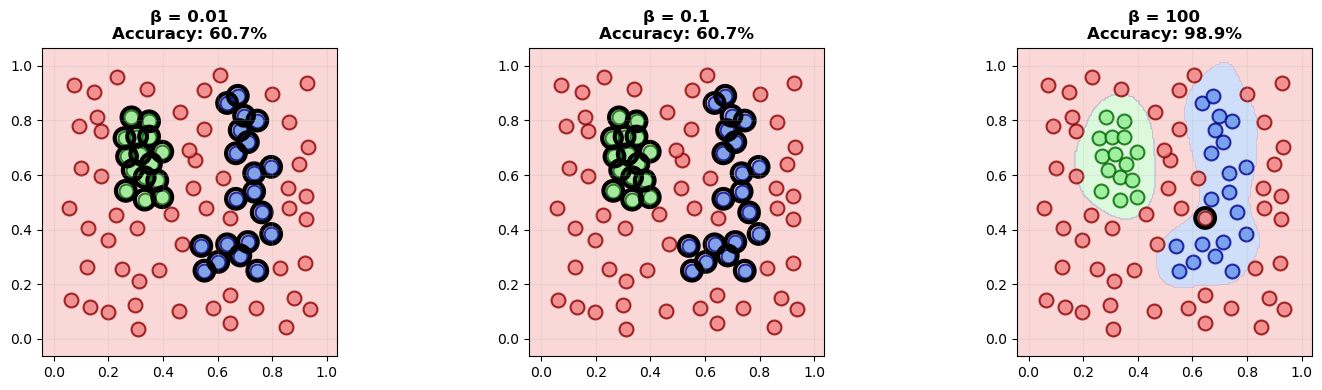

In [20]:
import numpy as np
import matplotlib.pyplot as plt


# Ensure y is 2D
if y.ndim == 1:
    y = y.reshape(1, -1)

print(f"Input shape: {x.shape}")
print(f"Output shape: {y.shape}")

# RBF kernel function
def compute_rbf_kernel(x, beta):
    N = x.shape[1]
    H = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            diff = x[:, i] - x[:, j]
            H[i, j] = np.exp(-beta * np.dot(diff, diff))
    return H

# One-vs-all encoding
def one_vs_all_encoding(y, C):
    if y.ndim == 1:
        y_flat = y
    else:
        y_flat = y.flatten()
    N = len(y_flat)
    Y = np.zeros((C, N))
    for c in range(C):
        Y[c, :] = (y_flat == c).astype(float)
    return Y

# Softmax function
def softmax(W, H):
    scores = W @ H
    scores = scores - np.max(scores, axis=0, keepdims=True)
    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
    return probs

# Cost and gradient
def softmax_cost(W, H, Y):
    N = Y.shape[1]
    probs = softmax(W, H)
    cost = -np.sum(Y * np.log(probs + 1e-10)) / N
    return cost

def softmax_gradient(W, H, Y):
    N = Y.shape[1]
    probs = softmax(W, H)
    grad = (probs - Y) @ H.T / N
    return grad

# Improved gradient descent with adaptive learning rate
def gradient_descent_improved(H, Y, alpha_init=1.0, max_iter=10000, verbose=False):
    C, N = Y.shape
    W = np.random.randn(C, N) * 0.01
    
    cost_history = []
    misclass_history = []
    alpha = alpha_init
    best_W = W.copy()
    best_misclass = N
    patience = 0
    
    for iteration in range(max_iter):
        # Compute cost and misclassification
        cost = softmax_cost(W, H, Y)
        cost_history.append(cost)
        
        probs = softmax(W, H)
        predictions = np.argmax(probs, axis=0)
        true_labels = np.argmax(Y, axis=0)
        misclass = np.sum(predictions != true_labels)
        misclass_history.append(misclass)
        
        if verbose and iteration % 1000 == 0:
            print(f"Iteration {iteration}: Cost = {cost:.4f}, Misclass = {misclass}, LR = {alpha:.4f}")
        
        # Track best model
        if misclass < best_misclass:
            best_misclass = misclass
            best_W = W.copy()
            patience = 0
        else:
            patience += 1
        
        # Compute gradient
        grad = softmax_gradient(W, H, Y)
        
        # Adaptive learning rate: reduce if oscillating
        if len(cost_history) > 10:
            recent_costs = cost_history[-10:]
            if max(recent_costs) - min(recent_costs) > 0.1:  # oscillating
                alpha *= 0.99  # gradually reduce
        
        # Update weights
        W = W - alpha * grad
        
        # Early stopping if converged or no improvement
        if patience > 1000 or (iteration > 100 and abs(cost_history[-1] - cost_history[-2]) < 1e-8):
            if verbose:
                print(f"Converged at iteration {iteration}")
            break
    
    return best_W, cost_history, misclass_history

# Train with better hyperparameters
def train_rbf_classifier_improved(x, y, beta_values, max_iter=10000):
    if y.ndim == 1:
        y_flat = y
    else:
        y_flat = y.flatten()
    
    C = len(np.unique(y_flat))
    Y = one_vs_all_encoding(y, C)
    
    results = {}
    
    for beta in beta_values:
        print(f"\n{'='*60}")
        print(f"Training with β = {beta}")
        print(f"{'='*60}")
        
        H = compute_rbf_kernel(x, beta)
        H_reg = H + 1e-6 * np.eye(H.shape[0])
        
        # Better learning rate selection
        if beta >= 10:
            alpha = 0.1  # Reduced for large beta
        elif beta >= 0.1:
            alpha = 0.3  # Reduced for medium beta
        else:
            alpha = 0.5  # Reduced for small beta
        
        # Train with improved method
        W, cost_history, misclass_history = gradient_descent_improved(
            H_reg, Y, alpha_init=alpha, max_iter=max_iter, verbose=True
        )
        
        results[beta] = {
            'W': W,
            'H': H_reg,
            'cost_history': cost_history,
            'misclass_history': misclass_history
        }
        
        # Final performance
        probs = softmax(W, H_reg)
        predictions = np.argmax(probs, axis=0)
        true_labels = y_flat.astype(int)
        accuracy = np.mean(predictions == true_labels)
        final_misclass = np.sum(predictions != true_labels)
        
        print(f"\n>>> Final Results:")
        print(f"    Accuracy: {accuracy*100:.2f}%")
        print(f"    Misclassification: {final_misclass}/{len(true_labels)}")
        print(f"    Training iterations: {len(cost_history)}")
    
    return results

# Train models
beta_values = [0.01, 0.1, 100]
results = train_rbf_classifier_improved(x, y, beta_values, max_iter=10000)

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, beta in enumerate(beta_values):
    ax = axes[idx]
    misclass_history = results[beta]['misclass_history']
    
    ax.plot(misclass_history, linewidth=2, color='darkblue')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Number of Misclassifications', fontsize=12)
    ax.set_title(f'β = {beta}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    
    # Add final value text
    final_val = misclass_history[-1]
    ax.text(0.95, 0.95, f'Final: {final_val}', 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
print("\n" + "="*60)
print("Improved misclassification history plots saved!")
print("="*60)

# Decision boundaries
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
x_np = x.T
y_np = y.flatten().astype(int)
colors = ['lightgreen', 'cornflowerblue', 'lightcoral']
edge_colors = ['darkgreen', 'darkblue', 'darkred']

for idx, beta in enumerate(beta_values):
    ax = axes2[idx]
    W = results[beta]['W']
    H = results[beta]['H']
    probs = softmax(W, H)
    predictions = np.argmax(probs, axis=0)
    
    # Create grid
    x_min, x_max = x_np[:, 0].min() - 0.1, x_np[:, 0].max() + 0.1
    y_min, y_max = x_np[:, 1].min() - 0.1, x_np[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()].T
    
    N_train = x.shape[1]
    N_grid = grid_points.shape[1]
    H_grid = np.zeros((N_grid, N_train))
    
    for i in range(N_grid):
        for j in range(N_train):
            diff = grid_points[:, i] - x[:, j]
            H_grid[i, j] = np.exp(-beta * np.dot(diff, diff))
    
    grid_probs = softmax(W, H_grid.T)
    grid_predictions = np.argmax(grid_probs, axis=0).reshape(xx.shape)
    
    ax.contourf(xx, yy, grid_predictions, levels=[-.5, .5, 1.5, 2.5], 
                colors=colors, alpha=0.3)
    
    for c in range(3):
        mask = y_np == c
        ax.scatter(x_np[mask, 0], x_np[mask, 1], 
                  c=[colors[c]], edgecolors=[edge_colors[c]], 
                  s=100, linewidth=1.5, alpha=0.8)
    
    misclassified = predictions != y_np
    if np.any(misclassified):
        ax.scatter(x_np[misclassified, 0], x_np[misclassified, 1],
                  facecolors='none', edgecolors='black', 
                  s=200, linewidth=3, marker='o')
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Add accuracy to title
    accuracy = np.mean(predictions == y_np) * 100
    ax.set_title(f'β = {beta}\nAccuracy: {accuracy:.1f}%', 
                fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
print("Improved decision boundary plots saved!")
print("="*60)

plt.show()

In [2]:
data = np.loadtxt(datapath + '2_eggs.csv', delimiter=',')
x = data[:2,:]
y = data[2,:][np.newaxis,:]

print(np.shape(x))
print(np.shape(y))

(2, 96)
(1, 96)


Final cost: 0.000201
Training accuracy: 100.00%


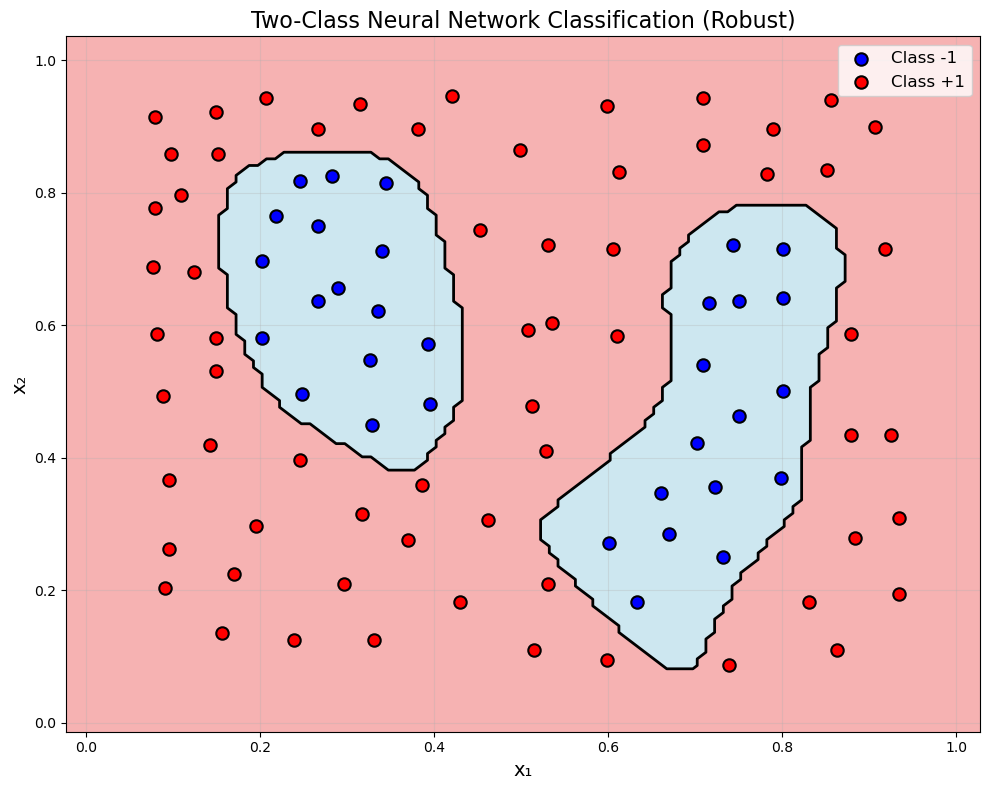

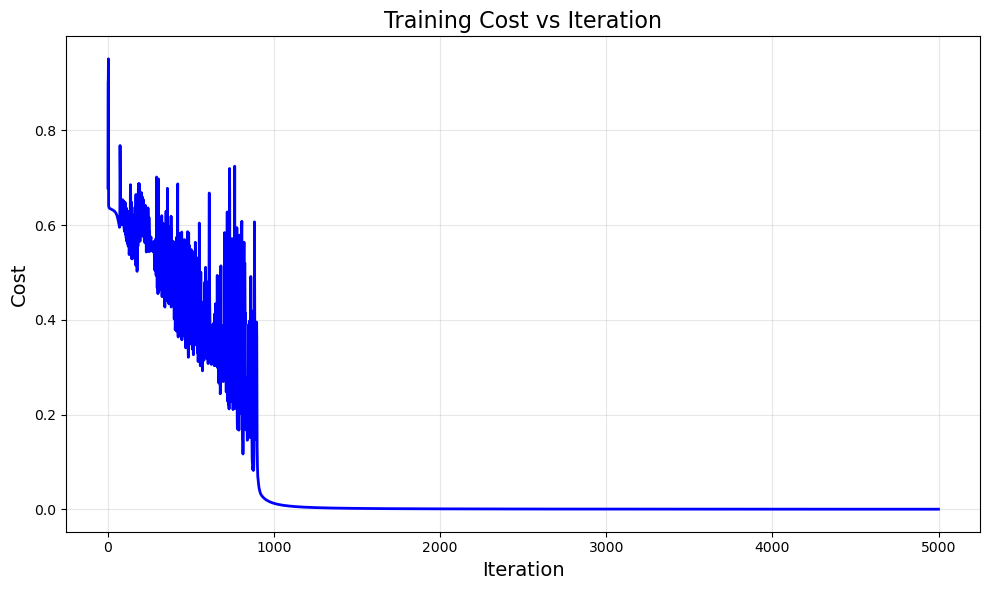

In [4]:
np.random.seed(42)

def activation(a):
    return anp.tanh(a)

def feature_transforms(a, w):
    for W in w:
        a = W[0] + anp.dot(a.T, W[1:])
        a = activation(a).T
    return a

def model(x, theta):
    f = feature_transforms(x, theta[0])
    a = theta[1][0] + anp.dot(f.T, theta[1][1:])
    return a.T

def softmax_cost(theta, x, y):
    predictions = model(x, theta)
    P = y.shape[1]
    z = y * predictions
    cost = (1/P) * anp.sum(anp.log(1 + anp.exp(-z)))
    return cost

gradient_func = grad(softmax_cost)

def network_initializer(layer_sizes, scale):
    weights = []
    for k in range(len(layer_sizes) - 1):
        U_k = layer_sizes[k]
        U_k_plus_1 = layer_sizes[k + 1]
        weight = scale * np.random.randn(U_k + 1, U_k_plus_1)
        weights.append(weight)
    theta_init = [weights[:-1], weights[-1]]
    return theta_init

def gradient_descent_momentum(theta_init, x, y, alpha, max_iters, verbose=True):
    theta = [[w.copy() for w in theta_init[0]], theta_init[1].copy()]
    cost_history = []
    
    velocity_hidden = [np.zeros_like(w) for w in theta[0]]
    velocity_final = np.zeros_like(theta[1])
    beta = 0.9  
    
    best_cost = float('inf')
    patience = 0
    max_patience = 150
    
    for iteration in range(max_iters):
        cost = softmax_cost(theta, x, y)
        cost_history.append(cost)
        
        grad = gradient_func(theta, x, y)
        
        for i in range(len(theta[0])):
            velocity_hidden[i] = beta * velocity_hidden[i] + (1 - beta) * grad[0][i]
            theta[0][i] = theta[0][i] - alpha * velocity_hidden[i]
        
        velocity_final = beta * velocity_final + (1 - beta) * grad[1]
        theta[1] = theta[1] - alpha * velocity_final
        
        if cost < best_cost - 1e-7:
            best_cost = cost
            patience = 0
        else:
            patience += 1
            if patience > max_patience:
                alpha *= 0.95
                patience = 0
        
        if verbose and (iteration % 100 == 0 or iteration == max_iters - 1):
            print(f"Iteration {iteration}, Cost: {cost:.6f}, LR: {alpha:.6f}")
    
    return theta, cost_history

def gradient_descent(theta_init, x, y, alpha, max_iters, verbose=True):
    theta = [[w.copy() for w in theta_init[0]], theta_init[1].copy()]
    cost_history = []
    best_cost = float('inf')
    patience = 0
    max_patience = 50
    
    for iteration in range(max_iters):
        cost = softmax_cost(theta, x, y)
        cost_history.append(cost)
        
        grad = gradient_func(theta, x, y)
        
        for i in range(len(theta[0])):
            theta[0][i] = theta[0][i] - alpha * grad[0][i]
        theta[1] = theta[1] - alpha * grad[1]
        
        if cost < best_cost:
            best_cost = cost
            patience = 0
        else:
            patience += 1
            if patience > max_patience:
                alpha *= 0.9
                patience = 0
    
    return theta, cost_history

# Visualization function
def plot_decision_boundary(theta, x, y, title="Decision Boundary"):
    h = 0.01
    x_min, x_max = x[0, :].min() - 0.1, x[0, :].max() + 0.1
    y_min, y_max = x[1, :].min() - 0.1, x[1, :].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()].T
    Z = model(grid_points, theta)
    Z = np.sign(Z.reshape(xx.shape))
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    contour = ax.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=['lightblue', 'lightcoral'], alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
    
    class_1 = y[0, :] == -1
    class_2 = y[0, :] == 1
    
    ax.scatter(x[0, class_1], x[1, class_1], c='blue', s=80, edgecolors='black', 
               linewidth=1.5, label='Class -1', zorder=3)
    ax.scatter(x[0, class_2], x[1, class_2], c='red', s=80, edgecolors='black', 
               linewidth=1.5, label='Class +1', zorder=3)
    
    ax.set_xlabel('x₁', fontsize=14)
    ax.set_ylabel('x₂', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    return fig

best_seed = None
best_final_cost = float('inf')
results = []

for seed in [42, 123, 456, 789, 2024]:
    np.random.seed(seed)
    
    layer_sizes = [2, 10, 10, 10, 10, 1]
    scale = 0.5
    alpha = 1.0
    max_iters = 5000
    
    theta_init = network_initializer(layer_sizes, scale)
    theta_final, cost_history = gradient_descent(theta_init, x, y, alpha, max_iters, verbose=False)
    
    final_cost = cost_history[-1]
    predictions = model(x, theta_final)
    predicted_labels = np.sign(predictions)
    accuracy = np.mean(predicted_labels == y) * 100
    
    results.append((seed, final_cost, accuracy))
    
    if final_cost < best_final_cost:
        best_final_cost = final_cost
        best_seed = seed


np.random.seed(best_seed)
layer_sizes = [2, 10, 10, 10, 10, 1]
scale = 0.5
alpha = 1.0
max_iters = 5000

theta_init = network_initializer(layer_sizes, scale)
theta_final, cost_history = gradient_descent(theta_init, x, y, alpha, max_iters, verbose=True)

predictions = model(x, theta_final)
predicted_labels = np.sign(predictions)
accuracy = np.mean(predicted_labels == y) * 100

print(f"Final cost: {cost_history[-1]:.6f}")
print(f"Training accuracy: {accuracy:.2f}%")

# Generate visualizations
fig2 = plot_decision_boundary(theta_final, x, y, "Two-Class Neural Network Classification (Robust)")
fig2.tight_layout()

fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(cost_history, linewidth=2, color='blue')
ax1.set_xlabel('Iteration', fontsize=14)
ax1.set_ylabel('Cost', fontsize=14)
ax1.set_title('Training Cost vs Iteration', fontsize=16)
ax1.grid(True, alpha=0.3)
fig1.tight_layout()



In [18]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

csvname = datapath + 'new_circle_data.csv'
data = np.loadtxt(csvname, delimiter=',')
x = data[:-1, :]                 
y = data[-1, :]                  

X = x.T                         
y = y.astype(int)                
         

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

def build_random_forest(X_train, y_train,
                        n_trees=200,
                        max_depth=None,
                        max_features=None,
                        random_state=0):
    rng = np.random.RandomState(random_state)
    N = X_train.shape[0]
    trees = []

    if max_features is None:
        max_features = int(np.sqrt(X_train.shape[1]))

    for i in range(n_trees):
        idx = rng.randint(0, N, size=N)
        Xb = X_train[idx]
        yb = y_train[idx]

        tree = DecisionTreeClassifier(
            max_depth=max_depth,
            max_features=max_features
        )
        tree.fit(Xb, yb)
        trees.append(tree)

    return trees


def rf_predict(trees, X):
    preds = np.array([t.predict(X) for t in trees]) 
    vote_sum = preds.sum(axis=0)
    y_hat = np.where(vote_sum >= 0, 1, -1)
    return y_hat

n_trees = 200
trees = build_random_forest(
    X_train, y_train,
    n_trees=n_trees,
    max_depth=None,     
    max_features=1,     
    random_state=0
)

indiv_acc = []
for t in trees:
    indiv_acc.append(accuracy_score(y_test, t.predict(X_test)))

indiv_acc = np.array(indiv_acc)

y_rf = rf_predict(trees, X_test)
rf_acc = accuracy_score(y_test, y_rf)

print("\nRandom forest accuracy on test set:")
print("  rf_acc =", rf_acc)

num_worse = np.sum(indiv_acc < rf_acc)
print(f"\nTrees with accuracy < random forest: {num_worse} / {n_trees}")



Random forest accuracy on test set:
  rf_acc = 0.9333333333333333

Trees with accuracy < random forest: 189 / 200


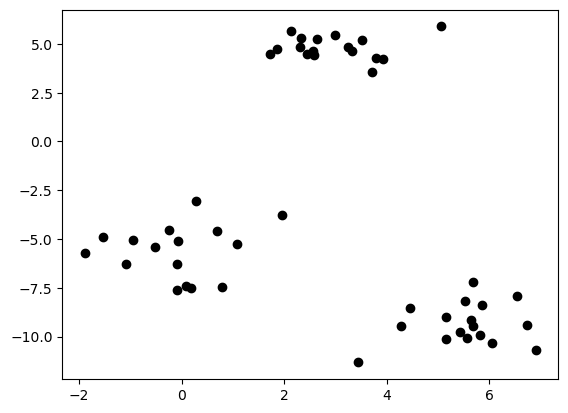

In [4]:
import matplotlib.pyplot as plt
from sklearn import datasets
%matplotlib inline

# Loading the data
P = 50 # Number of data points
blobs = datasets.make_blobs(n_samples=P,centers = 3,random_state=10)
data = np.transpose(blobs[0])

# scatter plot the dataset 
plt.scatter(data[0,:],data[1,:],c = 'k')
plt.show()

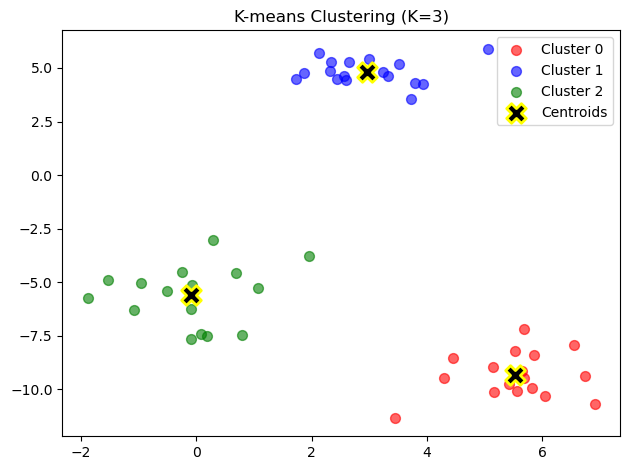

In [5]:
def kmeans(data, K, max_iters=100, tol=1e-6):
    d, P = data.shape
    
    random_indices = np.random.choice(P, K, replace=False)
    centroids = data[:, random_indices].copy()
    
    labels = np.zeros(P, dtype=int)
    
    for iteration in range(max_iters):
        for i in range(P):
            distances = np.zeros(K)
            for k in range(K):
                distances[k] = np.linalg.norm(data[:, i] - centroids[:, k])
            labels[i] = np.argmin(distances)
        
        new_centroids = np.zeros((d, K))
        for k in range(K):
            cluster_points = data[:, labels == k]
            if cluster_points.shape[1] > 0:  
                new_centroids[:, k] = np.mean(cluster_points, axis=1)
            else:
                new_centroids[:, k] = centroids[:, k]
        
        centroid_shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        
        if centroid_shift < tol:
            break
    
    total_distance = 0
    for k in range(K):
        cluster_points = data[:, labels == k]
        if cluster_points.shape[1] > 0:
            for i in range(cluster_points.shape[1]):
                total_distance += np.linalg.norm(cluster_points[:, i] - centroids[:, k])
    
    intra_cluster_distance = total_distance / P
    
    return centroids, labels, intra_cluster_distance

np.random.seed(42)

K = 3
centroids, labels, intra_cluster_dist = kmeans(data, K)

colors = ['red', 'blue', 'green']
for k in range(K):
    cluster_points = data[:, labels == k]
    plt.scatter(cluster_points[0, :], cluster_points[1, :], 
                c=colors[k], s=50, alpha=0.6, label=f'Cluster {k}')

plt.scatter(centroids[0, :], centroids[1, :], 
            c='black', s=200, marker='X', edgecolors='yellow', 
            linewidths=2, label='Centroids')

plt.title(f'K-means Clustering (K={K})')
plt.legend()
plt.tight_layout()
plt.show()